# **Cardiovascular Disease prediction using Machine Learning**



To predict the presence of cardiovascular disease in a patient using various machine learning algorithms and ensemble approach.

Datasets used:


Models used:
Logistic Regression
decision tree
KNN
Random Forest
Gradient boosting
Ensemble model

In [95]:
import pandas as pd

Loading the dataset using pandas

In [96]:
df = pd.read_csv('Cardiovascular_Disease_Dataset.csv')
df.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


Pre-processing the dataset

In [97]:
print(df.shape)
print(df.info())
df.describe()
df.isnull().sum()
df.duplicated().sum()

(1000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientid          1000 non-null   int64  
 1   age                1000 non-null   int64  
 2   gender             1000 non-null   int64  
 3   chestpain          1000 non-null   int64  
 4   restingBP          1000 non-null   int64  
 5   serumcholestrol    1000 non-null   int64  
 6   fastingbloodsugar  1000 non-null   int64  
 7   restingrelectro    1000 non-null   int64  
 8   maxheartrate       1000 non-null   int64  
 9   exerciseangia      1000 non-null   int64  
 10  oldpeak            1000 non-null   float64
 11  slope              1000 non-null   int64  
 12  noofmajorvessels   1000 non-null   int64  
 13  target             1000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 109.5 KB
None


np.int64(0)

In [98]:
X = df.drop(['target','patientid'], axis =1)
y = df['target']

X.head()

y.head()

print(y.value_counts())

target
1    580
0    420
Name: count, dtype: int64


After checking the database we split the database in training and testing set.

we use the

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.3, random_state = 42, stratify=y)

# Cross validation`

In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score


models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    # scale for models that are distance based
    if name in ["Logistic Regression", "KNN"]:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipeline = model  # Tree-based models no standdars scaler
    scores = cross_val_score(pipeline, X_train, y_train, cv=5)
    print(name)
    print("Cross-validation scores:", scores)
    print("Average accuracy:",round(scores.mean(),3))
    print()


Logistic Regression
Cross-validation scores: [0.92857143 0.95714286 0.96428571 0.97142857 0.95714286]
Average accuracy: 0.956

Decision Tree
Cross-validation scores: [0.95714286 0.95       0.88571429 0.95714286 0.95714286]
Average accuracy: 0.941

KNN
Cross-validation scores: [0.91428571 0.93571429 0.91428571 0.95714286 0.93571429]
Average accuracy: 0.931

Random Forest
Cross-validation scores: [0.95       0.98571429 0.97142857 0.97857143 0.97142857]
Average accuracy: 0.971

Gradient Boosting
Cross-validation scores: [0.95       1.         0.96428571 0.99285714 0.98571429]
Average accuracy: 0.979



# Logistic Regression

In [101]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

lr_pipeline.fit(X_train, y_train)

train_acc = lr_pipeline.score(X_train, y_train)

test_acc = lr_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")


Train Accuracy: 0.960
Test Accuracy: 0.980


In [102]:
#results of the model trained

y_pred = lr_pipeline.predict(X_test)




array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [103]:
# comparison between actual vs predicted values
y_pred = lr_pipeline.predict(X_test)
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

comparison

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
295,1,1
296,0,0
297,0,0
298,0,0


to evaluate the model we create the confusion matrix which gives us 4 values TN (True negatives), FP(False positives), FN(False negatives), TP(True positives).

In [104]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[123,   3],
       [  3, 171]])

the next step we calculate precision, recall, f1-score, support using confusion matrix. Here the importance is for recall as it measures the correct identified patients who are sick, which implies having low recall can be dangerous especially healthcare.

In [105]:
from sklearn.metrics import classification_report

print('\nClassification report \n', classification_report(y_test, y_pred))




Classification report 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.98      0.98      0.98       174

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



In [106]:
from sklearn.metrics import roc_curve, auc

y_prob = lr_pipeline.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

roc_auc

0.9981755154168946

As we have implemented baseline algorithm(Logistic regression) we now implement more ml algorithms. the next algorithm we implement is decision tree.

# Decision Tree

In [132]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state = 42,
    class_weight='balanced',
    max_depth=3,
)

dt_model.fit(X_train, y_train)

train_acc = dt_model.score(X_train, y_train)
test_acc = dt_model.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.944
Test Accuracy: 0.953


We make predictions after training the model and evaluate their performance

In [108]:
y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

y_pred_dt

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0])

In [109]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_dt))
print('\n Classification Report:\n', classification_report(y_test, y_pred_dt))

dt_auc = roc_auc_score(y_test, y_prob_dt)
print('Decision Tree AUC score:', dt_auc)

Confusion Matrix:
 [[117   9]
 [  5 169]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       126
           1       0.95      0.97      0.96       174

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

Decision Tree AUC score: 0.979064039408867


Decision tree splits the data to learn patterns. They can overfit meaning memorize from training data but we fix it when using ensemble methods.

Now we implement next machine learning algorithm which is KNN

K-Nearest neighbors

In [110]:
from sklearn import pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train )

train_acc = knn_pipeline.score(X_train, y_train)
test_acc = knn_pipeline.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.963
Test Accuracy: 0.930


making predicitions for KNN model and evaluating it

In [111]:
y_pred_knn = knn_pipeline.predict(X_test)
y_prob_knn = knn_pipeline.predict_proba(X_test)[:, 1]

In [112]:
from sklearn.metrics import confusion_matrix, classification_report,  roc_auc_score

print('Confusion_matrix:\n', confusion_matrix(y_test, y_pred_knn))
print('\n Classification Report:\n', classification_report(y_test, y_pred_knn))

knn_auc = roc_auc_score(y_test, y_prob_knn)
print('KNN AUC score:', knn_auc)

Confusion_matrix:
 [[118   8]
 [ 13 161]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       126
           1       0.95      0.93      0.94       174

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300

KNN AUC score: 0.9779465426017151


nSfter implemeting 3 simple ml models we now expand it further by integrating ensemble algorithms. This further increases the accuracy of the model.

In [134]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators = 200,
    max_depth = 3,
    class_weight = 'balanced',
    random_state = 42,

)

rf_model.fit(X_train, y_train)

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")


y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


Train Accuracy: 0.957
Test Accuracy: 0.977


Now we evaluate random forest model using confusion matrix, auc-roc, classification report.

In [114]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print('confusion_matrix:\n', confusion_matrix(y_test, y_pred_rf))
print('\n Classification Report:\n', classification_report(y_test, y_pred_rf))

rf_auc = roc_auc_score(y_test, y_prob_rf)
print('Random Forest AUC score:', rf_auc)

confusion_matrix:
 [[124   2]
 [  5 169]]

 Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       126
           1       0.99      0.97      0.98       174

    accuracy                           0.98       300
   macro avg       0.97      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300

Random Forest AUC score: 0.9972632731253421


next we use ensemble model called gradient boosting. this model creates trees in isolation and further tree correct the mistakes from previous ones.

In [135]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42

)

gb_model.fit(X_train, y_train)

train_acc = gb_model.score(X_train, y_train)
test_acc = gb_model.score(X_test, y_test)

print(f"Train Accuracy: {train_acc:.3f}")
print(f"Test Accuracy: {test_acc:.3f}")

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]


Train Accuracy: 1.000
Test Accuracy: 0.987


After this we put evaluate the model using confusion matrix and classification report based on that.

In [116]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

print('Confusion matrix: \n ',  confusion_matrix(y_test, y_pred_gb))
print ('\nClassification report: \n', classification_report(y_test, y_pred_gb))

gb_auc = roc_auc_score(y_test, y_prob_gb)
print('Gradient Boosting AUC score: ', gb_auc)

Confusion matrix: 
  [[124   2]
 [  2 172]]

Classification report: 
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.99      0.99      0.99       174

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300

Gradient Boosting AUC score:  0.9993158182813355


Bar chart- comparison of Train, test and cross validation

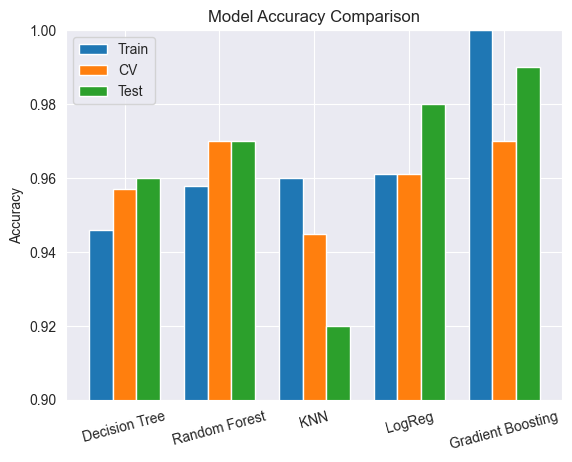

In [117]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'Random Forest', 'KNN', 'LogReg', 'Gradient Boosting']
train_acc = [0.946, 0.958, 0.96, 0.961, 1.00]
cv_acc = [0.957, 0.97, 0.945, 0.961, 0.97]
test_acc = [0.96, 0.97, 0.920, 0.980, 0.99]

x = np.arange(len(models))
width = 0.25

plt.bar(x - width, train_acc, width, label='Train')
plt.bar(x, cv_acc, width, label='CV')
plt.bar(x + width, test_acc, width, label='Test')

plt.xticks(x, models, rotation=15)
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.legend()
plt.show()

Amongst the 5 trained models Random forest classifier works best giving the highest recall and auc-roc score. Hence we fix that model for pickle.

Pickle is used to save the trained state of a model.

confusion matrix comparison chart

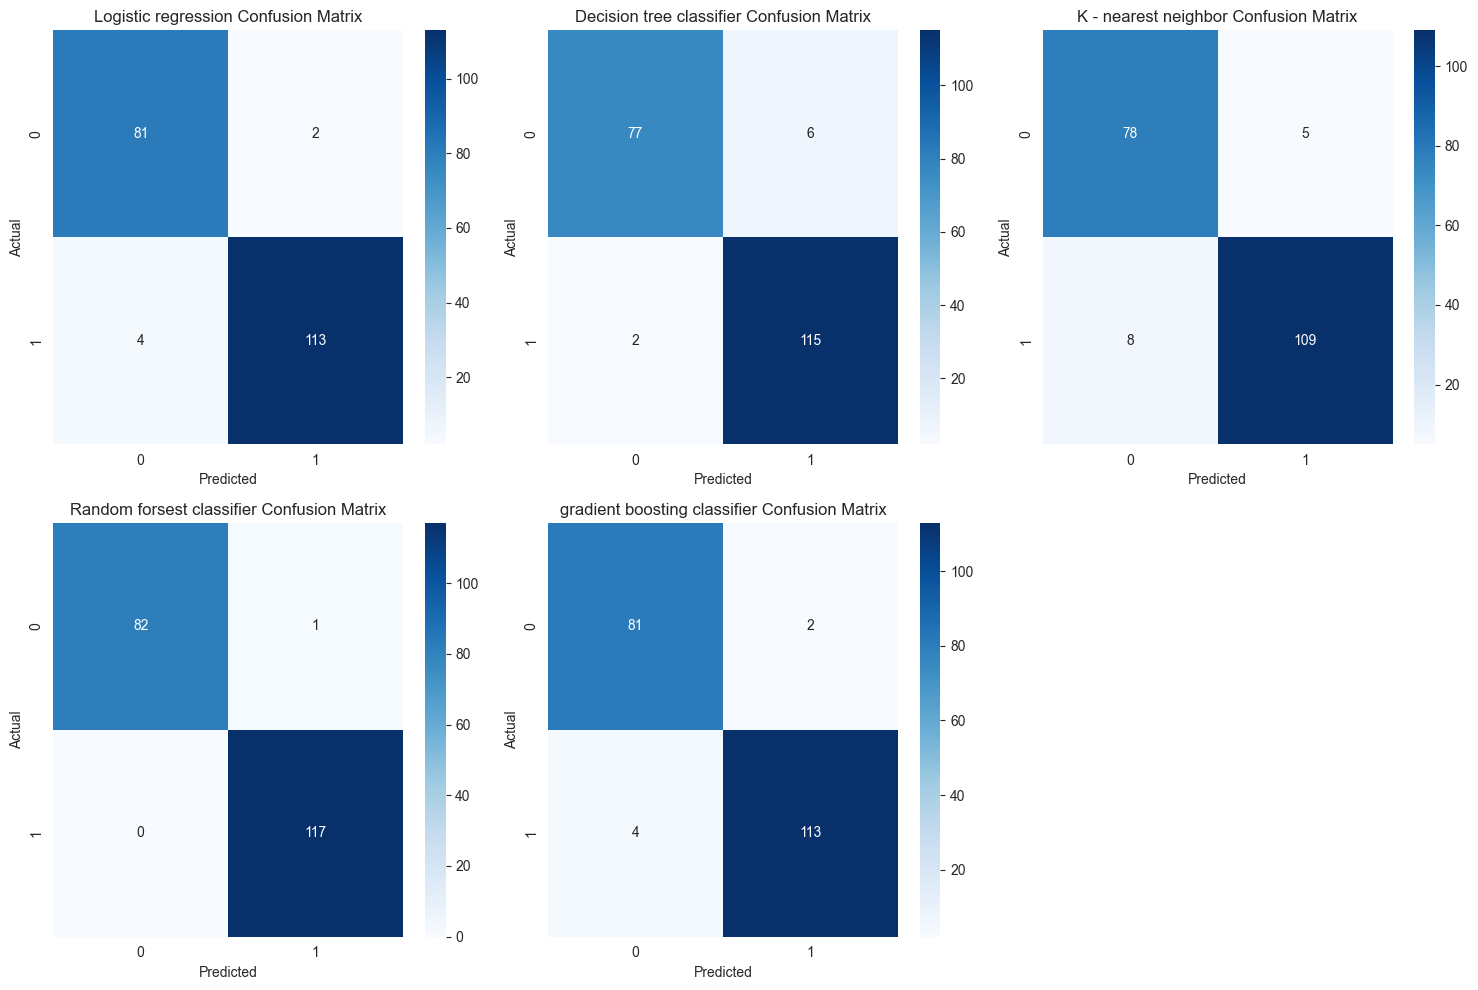

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example confusion matrices for 5 models
conf_matrices = {
    'Logistic regression': np.array([[81, 2],[4, 113]]),
    'Decision tree classifier': np.array([[77, 6],[2, 115]]),
    'K - nearest neighbor': np.array([[78, 5],[8, 109]]),
    'Random forsest classifier': np.array([[82, 1],[0, 117]]),
    'gradient boosting classifier': np.array([[81, 2],[4, 113]])
}

plt.figure(figsize=(15,10))
for i, (model, cm) in enumerate(conf_matrices.items(), 1):
    plt.subplot(2,3,i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model} Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()

classification report chart

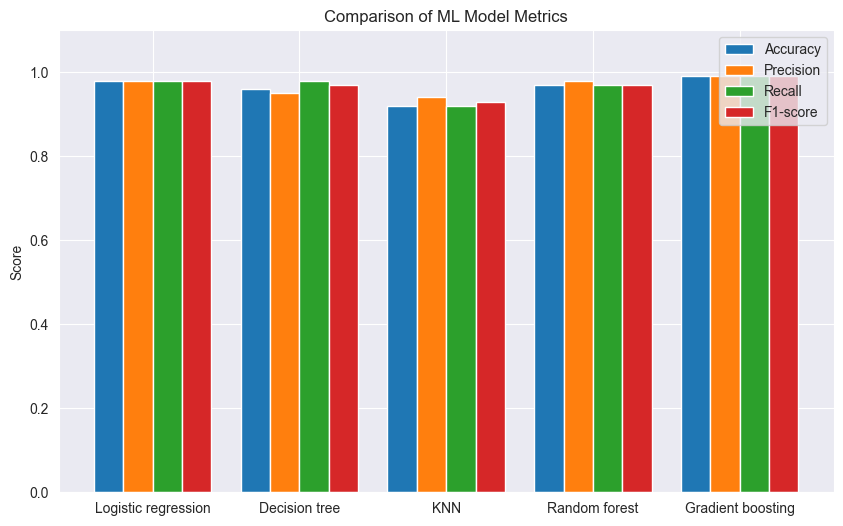

In [120]:
# Metrics for 5 models (replace with your real values)
models = ['Logistic regression', 'Decision tree', 'KNN', 'Random forest', 'Gradient boosting']
accuracy = [0.98, 0.96, 0.92, 0.97, 0.99]
precision = [0.98, 0.95, 0.94, 0.98, 0.99]
recall = [0.98, 0.98, 0.92, 0.97, 0.99]
f1_score = [0.98, 0.97, 0.93, 0.97, 0.99]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1_score, width, label='F1-score')

plt.xticks(x, models)
plt.ylim(0,1.1)
plt.ylabel('Score')
plt.title('Comparison of ML Model Metrics')
plt.legend()
plt.show()

In [136]:
from sklearn.ensemble import VotingClassifier

ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_pipeline),
        ('knn', knn_pipeline),
       ('dt', dt_model),
        ('rf', rf_model),
        ('gb', gb_model)
    ],
    voting='soft'
)

In [137]:
ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)

print("Train Accuracy:", ensemble.score(X_train, y_train))
print("Test Accuracy:", ensemble.score(X_test, y_test))

Train Accuracy: 0.9842857142857143
Test Accuracy: 0.98


In [123]:
y_prob = ensemble.predict_proba(X_test)[:, 1]

In [124]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[123   3]
 [  3 171]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       126
           1       0.98      0.98      0.98       174

    accuracy                           0.98       300
   macro avg       0.98      0.98      0.98       300
weighted avg       0.98      0.98      0.98       300



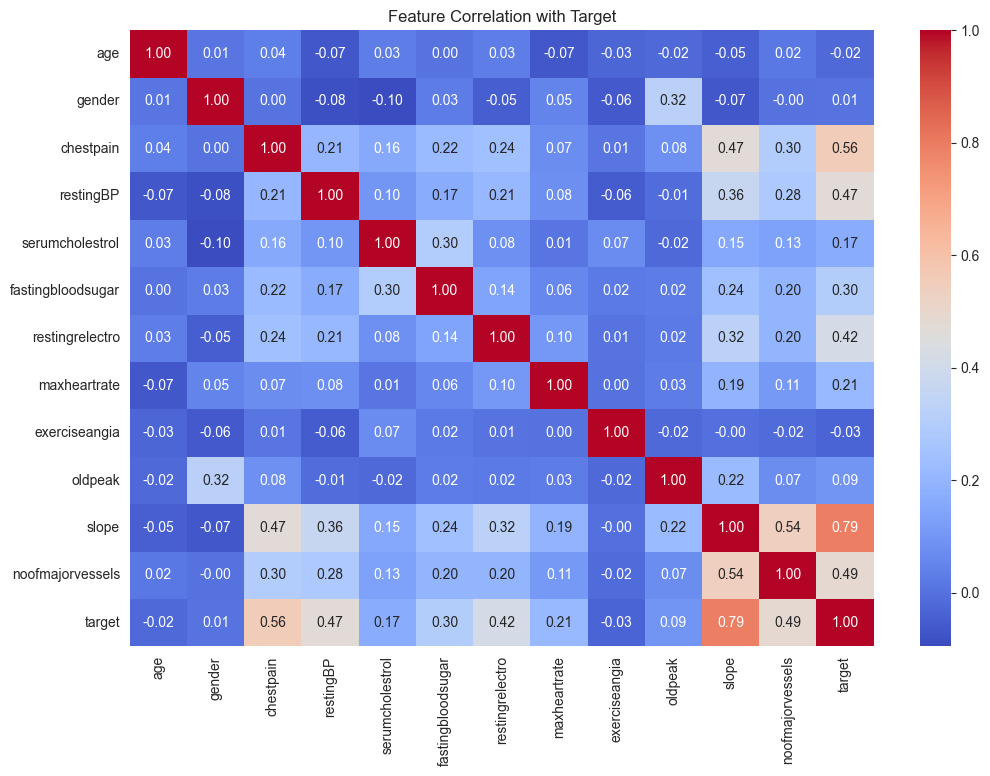

In [125]:
import seaborn as sns

plt.figure(figsize=(12,8))
corr = X_train.join(y_train).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Target')
plt.show()

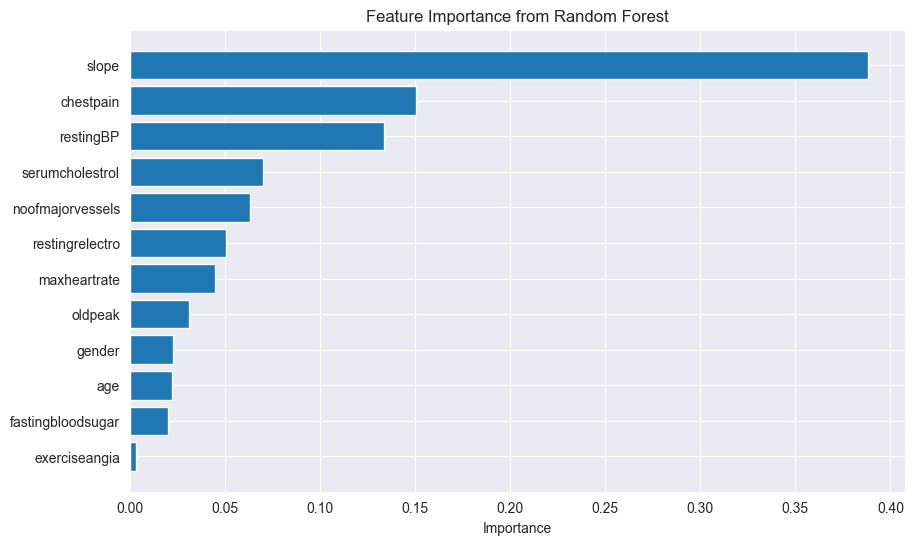

In [126]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Fit a random forest (example)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importances
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10,6))
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.gca().invert_yaxis()  # largest on top
plt.title('Feature Importance from Random Forest')
plt.xlabel('Importance')
plt.show()

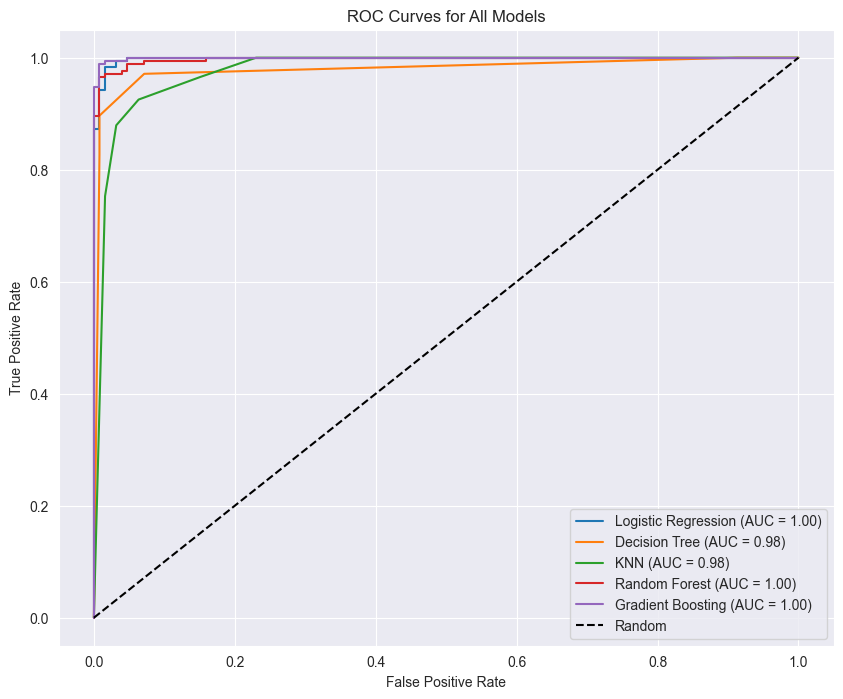

In [138]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Assuming you have already fitted your models
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_model,
    "KNN": knn_pipeline,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Get probability predictions
    if 'pipeline' in str(type(model)).lower():  # For pipelines
        y_prob = model.predict_proba(X_test)[:, 1]
    else:  # For tree models
        y_prob = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

# Plot random guess line
plt.plot([0, 1], [0, 1], 'k--', label='Random')

plt.title('ROC Curves for All Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [140]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Numerical and categorical features
numerical_features = ['age', 'restingBP', 'serumcholestrol', 'maxheartrate', 'oldpeak']
categorical_features = ['chestpain', 'slope', 'noofmajorvessels']

# Without one-hot
pipeline_num = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])
score_num = cross_val_score(pipeline_num, df[numerical_features + categorical_features], df['target'], cv=5).mean()

# With one-hot
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)
pipeline_ohe = Pipeline([
    ('preprocessor', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])
score_ohe = cross_val_score(pipeline_ohe, df[numerical_features + categorical_features], df['target'], cv=5).mean()

print(f"Score without one-hot: {score_num:.4f}")
print(f"Score with one-hot: {score_ohe:.4f}")

Score without one-hot: 0.9530
Score with one-hot: 0.9500
